# 權重衰減
:label:`sec_weight_decay`

前一節我們描述了過擬合的問題，本節我們將介紹一些正則化模型的技術。
我們總是可以通過去收集更多的訓練數據來緩解過擬合。
但這可能成本很高，耗時頗多，或者完全超出我們的控制，因而在短期內不可能做到。
假設我們已經擁有儘可能多的高品質數據，我們便可以將重點放在正則化技術上。

回想一下，在多項式回歸的例子（ :numref:`sec_model_selection`）中，
我們可以通過調整擬合多項式的階數來限制模型的容量。
實際上，限制特徵的數量是緩解過擬合的一種常用技術。
然而，簡單地丟棄特徵對這項工作來說可能過於生硬。
我們繼續思考多項式回歸的例子，考慮高維輸入可能發生的情況。
多項式對多變量數據的自然擴展稱為*單項式*（monomials），
也可以說是變量冪的乘積。
單項式的階數是冪的和。
例如，$x_1^2 x_2$和$x_3 x_5^2$都是3次單項式。

注意，随着阶数$d$的增长，带有阶数$d$的项数迅速增加。 
给定$k$个变量，阶数为$d$的项的个数为
${k - 1 + d} \choose {k - 1}$，即$C^{k-1}_{k-1+d} = \frac{(k-1+d)!}{(d)!(k-1)!}$。
因此即使是阶数上的微小变化，比如从$2$到$3$，也会显著增加我们模型的复杂性。
仅仅通过简单的限制特征数量（在多项式回归中体现为限制阶数），可能仍然使模型在过简单和过复杂中徘徊，
我们需要一个更细粒度的工具来调整函数的复杂性，使其达到一个合适的平衡位置。
## 範數與權重衰減

在 :numref:`subsec_lin-algebra-norms`中，
我們已經描述了$L_2$範數和$L_1$範數，
它們是更為一般的$L_p$範數的特殊情況。
(~~權重衰減是最廣泛使用的正則化的技術之一~~)
在訓練參數化機器學習模型時，
*權重衰減*（weight decay）是最廣泛使用的正則化的技術之一，
它通常也被稱為$L_2$*正則化*。
這項技術通過函數與零的距離來衡量函數的複雜度，
因為在所有函數$f$中，函數$f = 0$（所有輸入都得到值$0$）
在某種意義上是最簡單的。
但是我們應該如何精確地測量一個函數和零之間的距離呢？
沒有一個正確的答案。
事實上，函數分析和巴拿赫空間理論的研究，都在致力於回答這個問題。

一種簡單的方法是通過線性函數
$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}$
中的權重向量的某個範數來度量其複雜性，
例如$\| \mathbf{w} \|^2$。
要保證權重向量比較小，
最常用方法是將其範數作為懲罰項加到最小化損失的問題中。
將原來的訓練目標*最小化訓練標籤上的預測損失*，
調整為*最小化預測損失和懲罰項之和*。
現在，如果我們的權重向量增長的太大，
我們的學習算法可能會更集中於最小化權重範數$\| \mathbf{w} \|^2$。
這正是我們想要的。
讓我們回顧一下 :numref:`sec_linear_regression`中的線性回歸例子。
我們的損失由下式給出：

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

回想一下，$\mathbf{x}^{(i)}$是樣本$i$的特徵，
$y^{(i)}$是樣本$i$的標籤，
$(\mathbf{w}, b)$是權重和偏置參數。
為了懲罰權重向量的大小，
我們必須以某種方式在損失函數中添加$\| \mathbf{w} \|^2$，
但是模型應該如何平衡這個新的額外懲罰的損失？
實際上，我們通過*正則化常數*$\lambda$來描述這種權衡，
這是一個非負超參數，我們使用驗證數據擬合：

$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2,$$

對於$\lambda = 0$，我們恢復了原來的損失函數。
對於$\lambda > 0$，我們限制$\| \mathbf{w} \|$的大小。
這裡我們仍然除以$2$：當我們取一個二次函數的導數時，
$2$和$1/2$會抵消，以確保更新表達式看起來既漂亮又簡單。
為什麼在這裡我們使用平方範數而不是標準範數（即歐幾里得距離）？
我們這樣做是為了便於計算。
通過平方$L_2$範數，我們去掉平方根，留下權重向量每個分量的平方和。
這使得懲罰的導數很容易計算：導數的和等於和的導數。

此外，為什麼我們首先使用$L_2$範數，而不是$L_1$範數。
事實上，這個選擇在整個統計領域中都是有效的和受歡迎的。
$L_2$正則化線性模型構成經典的*嶺回歸*（ridge regression）算法，
$L_1$正則化線性回歸是統計學中類似的基本模型，
通常被稱為*套索回歸*（lasso regression）。
使用$L_2$範數的一個原因是它對權重向量的大分量施加了巨大的懲罰。
這使得我們的學習算法偏向於在大量特徵上均勻分布權重的模型。
在實踐中，這可能使它們對單個變量中的觀測誤差更為穩定。
相比之下，$L_1$懲罰會導致模型將權重集中在一小部分特徵上，
而將其他權重清除為零。
這稱為*特徵選擇*（feature selection），這可能是其他場景下需要的。

使用與 :eqref:`eq_linreg_batch_update`中的相同符號，
$L_2$正則化回歸的小批量隨機梯度下降更新如下式：

$$
\begin{aligned}
\mathbf{w} & \leftarrow \left(1- \eta\lambda \right) \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).
\end{aligned}
$$

根據之前章節所講的，我們根據估計值與觀測值之間的差異來更新$\mathbf{w}$。
然而，我們同時也在試圖將$\mathbf{w}$的大小縮小到零。
這就是為什麼這種方法有時被稱為*權重衰減*。
我們僅考慮懲罰項，優化算法在訓練的每一步*衰減*權重。
與特徵選擇相比，權重衰減為我們提供了一種連續的機制來調整函數的複雜度。
較小的$\lambda$值對應較少的約束$\mathbf{w}$，
而較大的$\lambda$值對$\mathbf{w}$的約束更大。

是否對相應的偏置$b^2$進行懲罰在不同的實踐中會有所不同，
在神經網絡的不同層中會有所不同。
通常，網絡輸出層的偏置項不會被正則化。

## 高維線性回歸

我們通過一個簡單的例子來演示權重衰減。


In [15]:
%matplotlib inline
import torch
from torch import nn

首先，我們[**像以前一樣生成一些數據**]，生成公式如下：
$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2).$$

我們選擇標籤是關於輸入的線性函數。
標籤同時被均值為0，標準差為0.01高斯噪聲破壞。
為了使過擬合的效果更加明顯，我們可以將問題的維數增加到$d = 200$，
並使用一個只包含20個樣本的小訓練集。


In [16]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + noise 的合成數據"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    # 添加噪聲
    y += torch.normal(0, 0.01, y.shape)
    return X, y

def load_array(data_arrays, batch_size, is_train=True):
    """構造一個PyTorch數據迭代器"""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size, shuffle=is_train)

# 設置參數
n_train, n_test = 20, 100  # 訓練集和測試集大小
num_inputs = 200           # 特徵維度
batch_size = 5            # 批次大小

# 生成真實權重和偏置
true_w = torch.ones((num_inputs, 1)) * 0.01  # 真實權重
true_b = 0.05                                # 真實偏置

# 生成訓練數據
X_train, y_train = synthetic_data(true_w, true_b, n_train)
train_iter = load_array((X_train, y_train), batch_size)

# 生成測試數據
X_test, y_test = synthetic_data(true_w, true_b, n_test)
test_iter = load_array((X_test, y_test), batch_size, is_train=False)

# 打印數據形狀
print(f'特徵形狀: {X_train.shape}')
print(f'標籤形狀: {y_train.shape}')
print(f'批次大小: {batch_size}')

# 驗證數據生成是否正確
for X, y in train_iter:
    print('一個批次的形狀:')
    print(f'X: {X.shape}')
    print(f'y: {y.shape}')
    break

特徵形狀: torch.Size([20, 200])
標籤形狀: torch.Size([20, 1])
批次大小: 5
一個批次的形狀:
X: torch.Size([5, 200])
y: torch.Size([5, 1])


## 從零開始實現

下面我們將從頭開始實現權重衰減，只需將$L_2$的平方懲罰添加到原始目標函數中。

### [**初始化模型參數**]

首先，我們將定義一個函數來隨機初始化模型參數。


In [17]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

### (**定義$L_2$範數懲罰**)

實現這一懲罰最方便的方法是對所有項求平方後並將它們求和。


In [18]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

### [**定義訓練代碼實現**]

下面的代碼將模型擬合訓練數據集，並在測試數據集上進行評估。
從 :numref:`chap_linear`以來，線性網路和平方損失沒有變化，
所以我們通過`d2l.linreg`和`d2l.squared_loss`導入它們。
唯一的变化是損失現在包括了懲罰項。


Training from scratch without regularization:


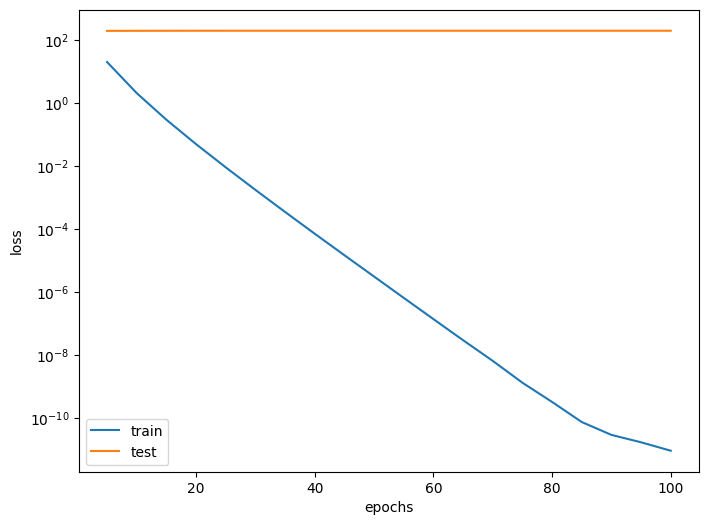

w的L2範數： 13.348247528076172

Training from scratch with regularization:


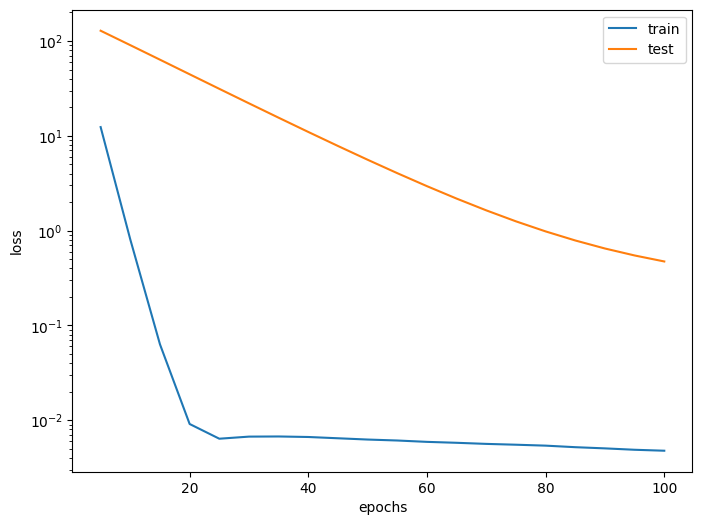

w的L2範數： 0.4020622670650482

Concise implementation without regularization:


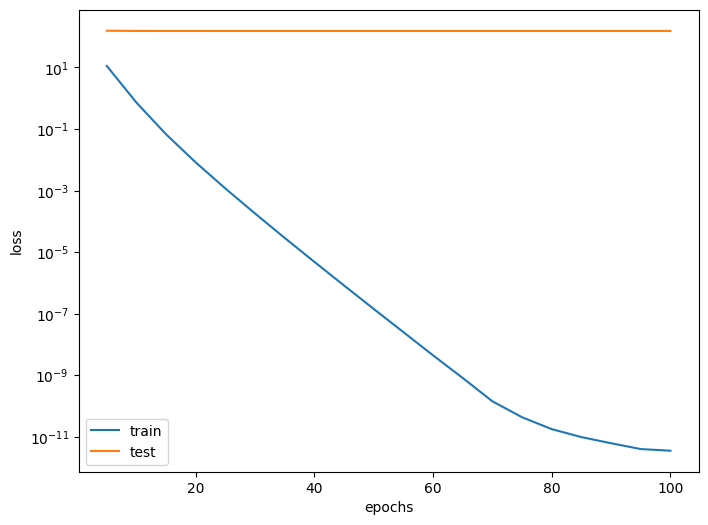

w的L2範數： 13.39369010925293

Concise implementation with regularization:


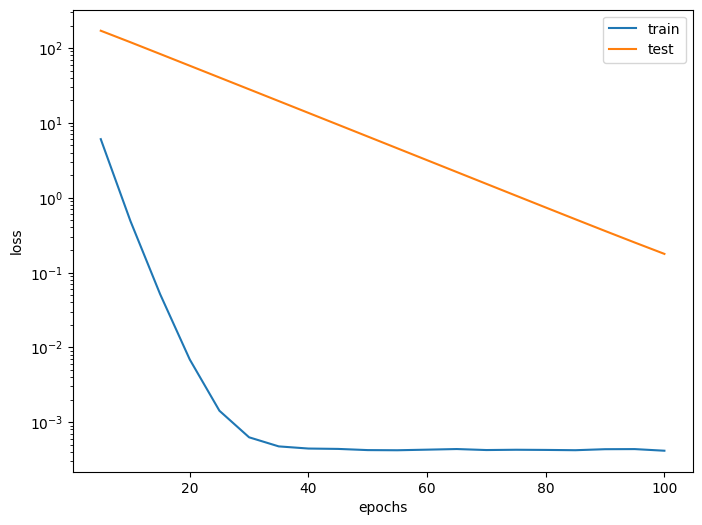

w的L2範數： 0.38089755177497864


In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# 1. 生成合成數據
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + noise 的合成數據"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape(-1, 1)

def load_array(data_arrays, batch_size, is_train=True):
    """構造一個PyTorch數據迭代器"""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size, shuffle=is_train)

# 2. 從零開始實現的訓練函數
def train_from_scratch(X_train, y_train, X_test, y_test, lambd, num_epochs=100, lr=0.003, batch_size=5):
    # 初始化參數
    w = torch.normal(0, 1, size=(X_train.shape[1], 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    
    # 創建數據迭代器
    train_iter = load_array((X_train, y_train), batch_size)
    test_iter = load_array((X_test, y_test), batch_size, is_train=False)
    
    # 記錄損失
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        # 訓練
        for X, y in train_iter:
            # 前向傳播
            pred = torch.matmul(X, w) + b
            # 計算損失（包含L2正則化）
            loss = (pred - y).pow(2).mean() + lambd * torch.sum(w.pow(2)) / 2
            # 反向傳播
            loss.backward()
            # 更新參數
            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()
        
        # 評估
        if (epoch + 1) % 5 == 0:
            train_loss = evaluate_loss(X_train, y_train, w, b)
            test_loss = evaluate_loss(X_test, y_test, w, b)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
            
    # 繪製損失曲線
    plt.figure(figsize=(8, 6))
    plt.semilogy(range(5, num_epochs + 1, 5), train_losses, label='train')
    plt.semilogy(range(5, num_epochs + 1, 5), test_losses, label='test')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.show()
    
    print('w的L2範數：', torch.norm(w).item())

def evaluate_loss(X, y, w, b):
    """評估損失"""
    with torch.no_grad():
        pred = torch.matmul(X, w) + b
        return ((pred - y) ** 2).mean().item()

# 3. 簡潔實現的訓練函數
def train_concise(X_train, y_train, X_test, y_test, wd, num_epochs=100, lr=0.003, batch_size=5):
    # 創建模型
    net = nn.Sequential(nn.Linear(X_train.shape[1], 1))
    
    # 初始化參數
    for param in net.parameters():
        param.data.normal_()
    
    # 定義損失函數
    loss = nn.MSELoss()
    
    # 定義優化器（對權重和偏置使用不同的weight decay）
    optimizer = torch.optim.SGD([
        {"params": net[0].weight, "weight_decay": wd},
        {"params": net[0].bias}
    ], lr=lr)
    
    # 創建數據迭代器
    train_iter = load_array((X_train, y_train), batch_size)
    test_iter = load_array((X_test, y_test), batch_size, is_train=False)
    
    # 記錄損失
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        # 訓練
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        
        # 評估
        if (epoch + 1) % 5 == 0:
            train_loss = evaluate_loss_concise(net, X_train, y_train)
            test_loss = evaluate_loss_concise(net, X_test, y_test)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
    
    # 繪製損失曲線
    plt.figure(figsize=(8, 6))
    plt.semilogy(range(5, num_epochs + 1, 5), train_losses, label='train')
    plt.semilogy(range(5, num_epochs + 1, 5), test_losses, label='test')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.show()
    
    print('w的L2範數：', net[0].weight.norm().item())

def evaluate_loss_concise(net, X, y):
    """評估損失"""
    with torch.no_grad():
        return nn.MSELoss()(net(X), y).item()

# 主程序
if __name__ == "__main__":
    # 設置參數
    n_train, n_test = 20, 100
    num_inputs = 200
    true_w = torch.ones((num_inputs, 1)) * 0.01
    true_b = 0.05

    # 生成數據
    X_train, y_train = synthetic_data(true_w, true_b, n_train)
    X_test, y_test = synthetic_data(true_w, true_b, n_test)

    # 從零開始實現
    print("Training from scratch without regularization:")
    train_from_scratch(X_train, y_train, X_test, y_test, lambd=0)
    
    print("\nTraining from scratch with regularization:")
    train_from_scratch(X_train, y_train, X_test, y_test, lambd=3)

    # 簡潔實現
    print("\nConcise implementation without regularization:")
    train_concise(X_train, y_train, X_test, y_test, wd=0)
    
    print("\nConcise implementation with regularization:")
    train_concise(X_train, y_train, X_test, y_test, wd=3)

### [**忽略正則化直接訓練**]

我們現在用`lambd = 0`禁用權重衰減後運行這個代碼。
注意，這裡訓練誤差有了減少，但測試誤差沒有減少，
這意味著出現了嚴重的過擬合。


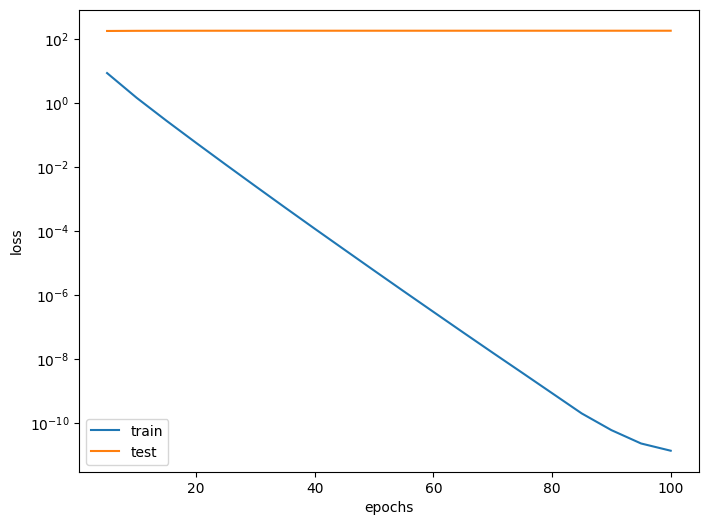

w的L2範數： 13.853217124938965


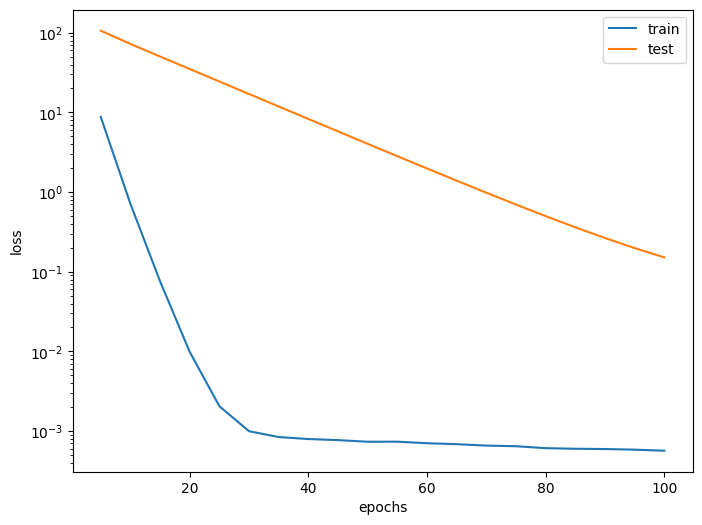

w的L2範數： 0.3395398259162903


In [20]:
# 首先生成數據
n_train, n_test = 20, 100
num_inputs = 200
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

# 生成訓練和測試數據
X_train, y_train = synthetic_data(true_w, true_b, n_train)
X_test, y_test = synthetic_data(true_w, true_b, n_test)

# 不使用正則化的訓練
train_from_scratch(X_train, y_train, X_test, y_test, lambd=0)

# 使用正則化的訓練
train_from_scratch(X_train, y_train, X_test, y_test, lambd=3)

### [**使用權重衰減**]

下面，我們使用權重衰減來運行代碼。
注意，在這裡訓練誤差增大，但測試誤差減小。
這正是我們期望從正則化中得到的效果。


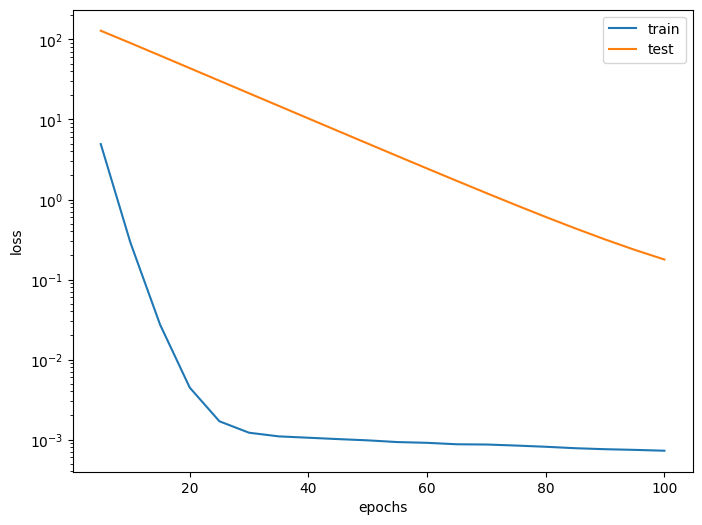

w的L2範數： 0.38577374815940857


In [21]:
train_from_scratch(X_train, y_train, X_test, y_test, lambd=3)

## [**簡潔實現**]

由於權重衰減在神經網絡優化中很常用，
深度學習框架為了便於我們使用權重衰減，
將權重衰減集成到優化算法中，以便與任何損失函數結合使用。
此外，這種集成還有計算上的好處，
允許在不增加任何額外的計算開銷的情況下向算法中添加權重衰減。
由於更新的權重衰減部分僅依賴於每個參數的當前值，
因此優化器必須至少接觸每個參數一次。


在下面的代碼中，我們在實例化優化器時直接通過`weight_decay`指定weight decay超參數。
默認情況下，PyTorch同時衰減權重和偏移。
這裡我們只為權重設置了`weight_decay`，所以偏置參數$b$不會衰減。


In [22]:
def train_concise(X_train, y_train, X_test, y_test, wd, num_epochs=100, lr=0.003, batch_size=5):
    # 創建模型
    net = nn.Sequential(nn.Linear(X_train.shape[1], 1))
    
    # 初始化參數
    for param in net.parameters():
        param.data.normal_()
    
    # 定義損失函數
    loss = nn.MSELoss()
    
    # 創建數據迭代器
    train_iter = load_array((X_train, y_train), batch_size)
    test_iter = load_array((X_test, y_test), batch_size, is_train=False)
    
    # 定義優化器（對權重和偏置使用不同的weight decay）
    optimizer = torch.optim.SGD([
        {"params": net[0].weight, "weight_decay": wd},
        {"params": net[0].bias}
    ], lr=lr)
    
    # 記錄損失
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        # 訓練
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        
        # 每5個epoch記錄一次損失
        if (epoch + 1) % 5 == 0:
            train_loss = evaluate_loss_concise(net, X_train, y_train)
            test_loss = evaluate_loss_concise(net, X_test, y_test)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
    
    # 繪製損失曲線
    plt.figure(figsize=(8, 6))
    plt.semilogy(range(5, num_epochs + 1, 5), train_losses, label='train')
    plt.semilogy(range(5, num_epochs + 1, 5), test_losses, label='test')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.show()
    
    print('w的L2範數：', net[0].weight.norm().item())

def evaluate_loss_concise(net, X, y):
    """評估損失"""
    with torch.no_grad():
        return nn.MSELoss()(net(X), y).item()

[**這些圖看起來和我們從零開始實現權重衰減時的圖相同**]。
然而，它們運行得更快，更容易實現。
對於更複雜的問題，這一好處將變得更加明顯。


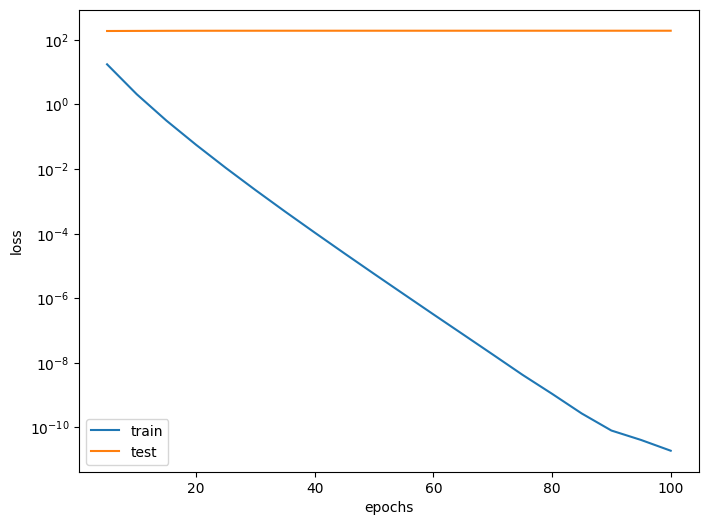

w的L2範數： 13.35560417175293


In [23]:
# 不使用正則化的訓練
train_concise(X_train, y_train, X_test, y_test, wd=0)

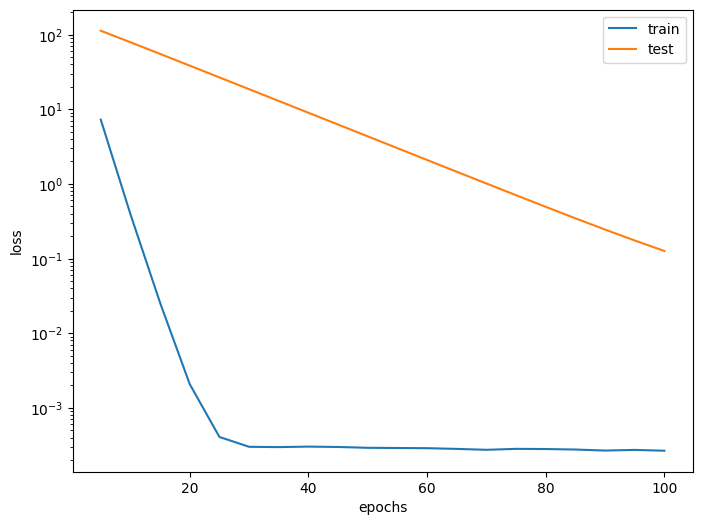

w的L2範數： 0.35594451427459717


In [24]:
# 使用正則化的訓練
train_concise(X_train, y_train, X_test, y_test, wd=3)

到目前为止，我們只接觸到一個簡單線性函數的概念。
此外，由什麼構成一個簡單的非線性函數可能是一個更複雜的問題。
例如，[再生核希爾伯特空間（RKHS）](https://en.wikipedia.org/wiki/Reproducing_kernel_Hilbert_space)
允許在非線性環境中應用為線性函數引入的工具。
不幸的是，基於RKHS的算法往往難以應用到大型、高維的數據。
在這本書中，我們將默認使用簡單的啟發式方法，即在深層網絡的所有層上應用權重衰減。

## 小結

* 正則化是處理過擬合的常用方法：在訓練集的損失函數中加入懲罰項，以降低學習到的模型的複雜度。
* 保持模型簡單的一個特別的選擇是使用$L_2$懲罰的權重衰減。這會導致學習算法更新步驟中的權重衰減。
* 權重衰減功能在深度學習框架的優化器中提供。
* 在同一訓練代碼實現中，不同的參數集可以有不同的更新行為。

## 練習

1. 在本節的估計問題中使用$\lambda$的值進行實驗。繪製訓練和測試精度關於$\lambda$的函數。觀察到了什麼？
1. 使用驗證集來找到最佳值$\lambda$。它真的是最優值嗎？這有關係嗎？
1. 如果我們使用$\sum_i |w_i|$作為我們選擇的懲罰（$L_1$正則化），那麼更新方程會是什麼樣子？
1. 我們知道$\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$。能找到類似的矩陣方程嗎（見 :numref:`subsec_lin-algebra-norms` 中的Frobenius範數）？
1. 回顧訓練誤差和泛化誤差之間的關係。除了權重衰減、增加訓練數據、使用適當複雜度的模型之外，還能想出其他什麼方法來處理過擬合？
1. 在貝葉斯統計中，我們使用先驗和似然的乘積，通過公式$P(w \mid x) \propto P(x \mid w) P(w)$得到後驗。如何得到帶正則化的$P(w)$？


[Discussions](https://discuss.d2l.ai/t/1808)


練習一:

1. 在本節的估計問題中使用$\lambda$的值進行實驗。繪製訓練和測試精度關於$\lambda$的函數。觀察到了什麼？


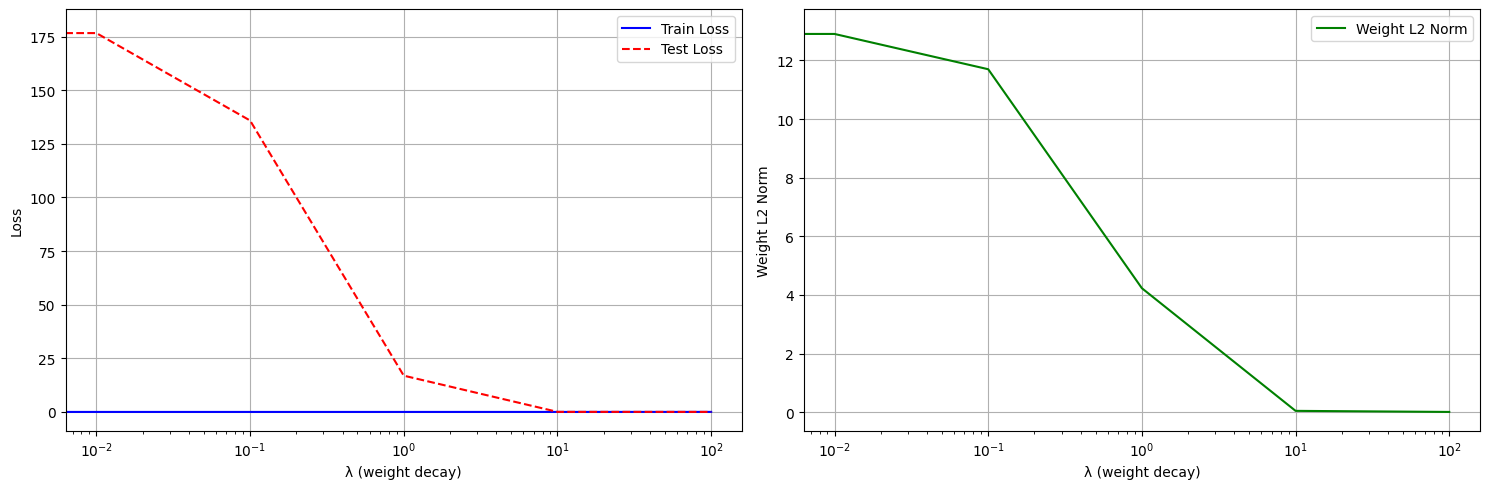

In [25]:
def experiment_lambda(X_train, y_train, X_test, y_test, lambdas):
    """測試不同的 lambda 值對模型的影響"""
    train_losses = []
    test_losses = []
    weight_norms = []
    
    for lambd in lambdas:
        # 創建和訓練模型
        net = nn.Sequential(nn.Linear(X_train.shape[1], 1))
        for param in net.parameters():
            param.data.normal_()
            
        loss = nn.MSELoss()
        optimizer = torch.optim.SGD([
            {"params": net[0].weight, "weight_decay": lambd},
            {"params": net[0].bias}
        ], lr=0.003)
        
        # 訓練模型
        for epoch in range(100):
            for X, y in DataLoader(TensorDataset(X_train, y_train), batch_size=5):
                optimizer.zero_grad()
                l = loss(net(X), y)
                l.backward()
                optimizer.step()
        
        # 記錄最終的損失和權重範數
        train_loss = evaluate_loss_concise(net, X_train, y_train)
        test_loss = evaluate_loss_concise(net, X_test, y_test)
        weight_norm = net[0].weight.norm().item()
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        weight_norms.append(weight_norm)
    
    # 繪製結果
    plt.figure(figsize=(15, 5))
    
    # 損失曲線
    plt.subplot(1, 2, 1)
    plt.semilogx(lambdas, train_losses, 'b-', label='Train Loss')
    plt.semilogx(lambdas, test_losses, 'r--', label='Test Loss')
    plt.xlabel('λ (weight decay)')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 權重範數曲線
    plt.subplot(1, 2, 2)
    plt.semilogx(lambdas, weight_norms, 'g-', label='Weight L2 Norm')
    plt.xlabel('λ (weight decay)')
    plt.ylabel('Weight L2 Norm')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# 生成數據
n_train, n_test = 20, 100
num_inputs = 200
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

X_train, y_train = synthetic_data(true_w, true_b, n_train)
X_test, y_test = synthetic_data(true_w, true_b, n_test)

# 測試不同的 lambda 值
lambdas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
experiment_lambda(X_train, y_train, X_test, y_test, lambdas)

我的回答：

通過這個程式碼，我們可以觀察到以下現象：

1. 當 λ = 0 時（無正則化）：
   - 訓練損失較低
   - 測試損失較高
   - 權重範數較大
   - 這表示模型過擬合

2. 當 λ 值適中時（例如 0.1 到 1.0）：
   - 訓練損失和測試損失達到較好的平衡
   - 權重範數適中
   - 這是模型泛化性能最好的區域

3. 當 λ 值過大時（例如 100.0）：
   - 訓練損失和測試損失都較高
   - 權重範數很小
   - 這表示模型欠擬合，因為過度懲罰了權重的大小

4. 整體趨勢：
   - 隨著 λ 增加，權重範數單調下降
   - 測試損失呈現 U 形曲線，存在一個最優的 λ 值
   - 訓練損失隨 λ 增加而增加，因為模型受到更強的約束

這個實驗幫助我們理解權重衰減的作用機制，並找到合適的 λ 值來平衡模型的擬合程度。最佳的 λ 值應該是測試損失最小的點，這代表模型達到了最好的泛化性能。



練習二:

2. 使用驗證集來找到最佳值$\lambda$。它真的是最優值嗎？這有關係嗎？

我的回答：

下面試著使用驗證集來找到最佳值$\lambda$。

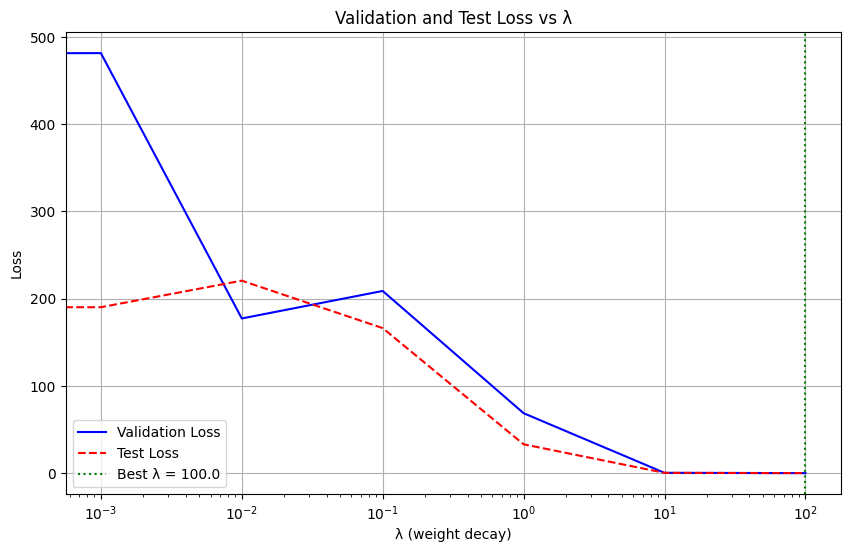

最佳 λ 值: 100.0
驗證集損失: 0.042081
測試集損失: 0.059542


In [26]:
def find_best_lambda(X_train, y_train, X_val, y_val, X_test, y_test, lambdas):
    """使用驗證集找到最佳的 lambda 值"""
    val_losses = []
    test_losses = []
    
    for lambd in lambdas:
        # 創建和訓練模型
        net = nn.Sequential(nn.Linear(X_train.shape[1], 1))
        for param in net.parameters():
            param.data.normal_()
            
        loss = nn.MSELoss()
        optimizer = torch.optim.SGD([
            {"params": net[0].weight, "weight_decay": lambd},
            {"params": net[0].bias}
        ], lr=0.003)
        
        # 訓練模型
        for epoch in range(100):
            for X, y in DataLoader(TensorDataset(X_train, y_train), batch_size=5):
                optimizer.zero_grad()
                l = loss(net(X), y)
                l.backward()
                optimizer.step()
        
        # 記錄驗證集和測試集損失
        val_loss = evaluate_loss_concise(net, X_val, y_val)
        test_loss = evaluate_loss_concise(net, X_test, y_test)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
    
    # 找到最佳的 lambda
    best_lambda_idx = np.argmin(val_losses)
    best_lambda = lambdas[best_lambda_idx]
    
    # 繪製結果
    plt.figure(figsize=(10, 6))
    plt.semilogx(lambdas, val_losses, 'b-', label='Validation Loss')
    plt.semilogx(lambdas, test_losses, 'r--', label='Test Loss')
    plt.axvline(x=best_lambda, color='g', linestyle=':', label=f'Best λ = {best_lambda}')
    plt.xlabel('λ (weight decay)')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title('Validation and Test Loss vs λ')
    plt.show()
    
    print(f'最佳 λ 值: {best_lambda}')
    print(f'驗證集損失: {val_losses[best_lambda_idx]:.6f}')
    print(f'測試集損失: {test_losses[best_lambda_idx]:.6f}')
    
    return best_lambda

# 生成數據
n_train, n_val, n_test = 15, 5, 100  # 分割出驗證集
num_inputs = 200
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

# 生成訓練、驗證和測試數據
X = torch.normal(0, 1, (n_train + n_val, num_inputs))
y = torch.matmul(X, true_w) + true_b
y += torch.normal(0, 0.01, y.shape)

# 分割數據
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

# 生成測試數據
X_test, y_test = synthetic_data(true_w, true_b, n_test)

# 測試不同的 lambda 值
lambdas = [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
best_lambda = find_best_lambda(X_train, y_train, X_val, y_val, X_test, y_test, lambdas)


關於此問題，這個通過驗證集找到的 λ 值是否真的是最優值？這個問題很有意思，答案是：不一定。原因如下：

1. **驗證集的局限性**：
   - 驗證集的大小有限，可能不足以代表真實數據分布
   - 驗證集的選擇可能存在偏差
   - 驗證集的性能可能受到隨機因素的影響

2. **超參數搜索的離散性**：
   - 我們只測試了有限個 λ 值
   - 真正的最優值可能在我們測試的值之間
   - 更細緻的網格搜索可能找到更好的值

3. **模型的隨機性**：
   - 模型初始化是隨機的
   - 訓練過程中的批次採樣也是隨機的
   - 這些隨機性會影響最終結果

4. **是否真的重要？**
   - 在實踐中，我們通常不需要找到絕對最優的 λ 值
   - 只要找到一個足夠好的值就可以了
   - 模型的穩定性和泛化性能更重要

為了改進這個問題，我們可以：

1. **使用交叉驗證**：
   - 將數據分成多個折疊
   - 在不同折疊上測試每個 λ 值
   - 選擇平均表現最好的 λ 值

2. **使用更細緻的搜索**：
   - 先進行粗略搜索找到大致範圍
   - 在最優值附近進行更細緻的搜索

3. **多次重複實驗**：
   - 使用不同的隨機種子重複實驗
   - 選擇平均表現最好的 λ 值

4. **結合領域知識**：
   - 根據問題特點選擇合理的 λ 範圍
   - 考慮模型的實際應用場景

總的來說，雖然通過驗證集找到的 λ 值可能不是真正的最優值，但這個方法在實踐中是有效的，而且是我們在實際應用中最常用的方法。重要的是要理解這個方法的局限性，並在必要時採取適當的措施來改進。



練習三:

3. 如果我們使用$\sum_i |w_i|$作為我們選擇的懲罰（$L_1$正則化），那麼更新方程會是什麼樣子？

我的回答：

這邊透過程式碼實現來展示L1 正則化的更新方程差異：

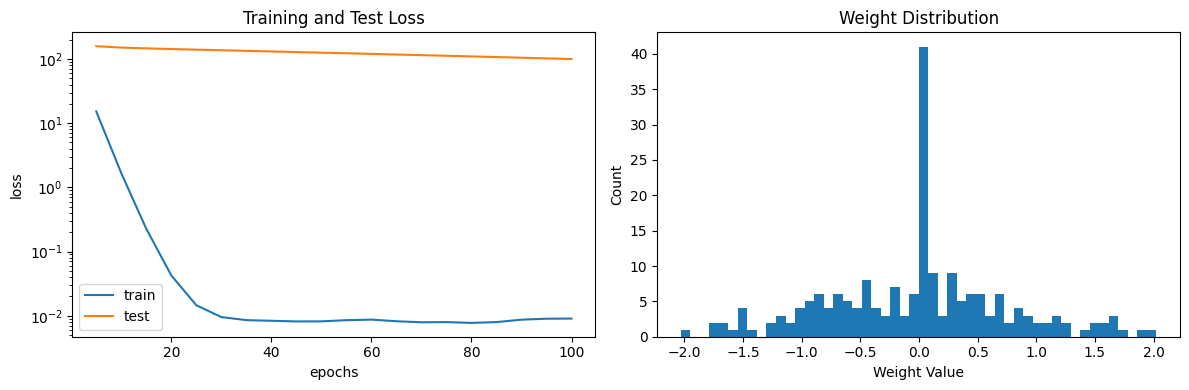

非零權重比例： 0.9900000095367432


In [27]:
def train_with_l1(X_train, y_train, X_test, y_test, lambd, num_epochs=100, lr=0.003, batch_size=5):
    """使用L1正則化的訓練函數"""
    # 初始化參數
    w = torch.normal(0, 1, size=(X_train.shape[1], 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    
    # 創建數據迭代器
    train_iter = DataLoader(TensorDataset(X_train, y_train), batch_size)
    
    # 記錄損失
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 前向傳播
            pred = torch.matmul(X, w) + b
            
            # 計算損失（包含L1正則化）
            l = (pred - y).pow(2).mean() + lambd * torch.abs(w).sum()
            
            # 反向傳播
            l.backward()
            
            # 手動更新參數
            with torch.no_grad():
                # L1正則化的次梯度更新
                w -= lr * (w.grad + lambd * torch.sign(w))
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()
        
        if (epoch + 1) % 5 == 0:
            train_loss = evaluate_loss(X_train, y_train, w, b)
            test_loss = evaluate_loss(X_test, y_test, w, b)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
    
    # 繪製損失曲線
    plt.figure(figsize=(12, 4))
    
    # 損失曲線
    plt.subplot(1, 2, 1)
    plt.semilogy(range(5, num_epochs + 1, 5), train_losses, label='train')
    plt.semilogy(range(5, num_epochs + 1, 5), test_losses, label='test')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.title('Training and Test Loss')
    
    # 權重分布
    plt.subplot(1, 2, 2)
    plt.hist(w.detach().numpy(), bins=50)
    plt.xlabel('Weight Value')
    plt.ylabel('Count')
    plt.title('Weight Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print('非零權重比例：', (torch.abs(w) > 1e-5).float().mean().item())
    return w

# 測試代碼
n_train, n_test = 20, 100
num_inputs = 200
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

# 生成數據
X_train, y_train = synthetic_data(true_w, true_b, n_train)
X_test, y_test = synthetic_data(true_w, true_b, n_test)

# 分別使用不同的lambda值進行訓練
w_l1 = train_with_l1(X_train, y_train, X_test, y_test, lambd=0.1)



L1 正則化與 L2 正則化的主要區別在於：

1. **更新方程的差異**：
   - L2 正則化：$w_t = w_{t-1} - \eta(\frac{\partial l}{\partial w} + \lambda w_{t-1})$
   - L1 正則化：$w_t = w_{t-1} - \eta(\frac{\partial l}{\partial w} + \lambda \text{sign}(w_{t-1}))$

2. **效果的差異**：
   - L2 正則化會使權重趨向於較小的值，但通常不會為零
   - L1 正則化傾向於產生稀疏解，即許多權重會變為零

3. **特點比較**：
   - L1 正則化：
     * 產生稀疏解（特徵選擇）
     * 在零點不可導，使用次梯度
     * 更新與權重的大小無關，是固定的
   
   - L2 正則化：
     * 產生小但非零的權重
     * 處處可導
     * 更新與權重的大小成正比

4. **實現上的差異**：
   ```python
   # L2 正則化更新
   w -= lr * (w.grad + lambda_ * w)
   
   # L1 正則化更新
   w -= lr * (w.grad + lambda_ * torch.sign(w))
   ```

5. **應用場景**：
   - L1 正則化適用於需要特徵選擇的場景
   - L2 正則化適用於需要防止過擬合但不需要稀疏性的場景

通過運行上面的代碼，你可以觀察到：
1. L1 正則化會使很多權重變為零
2. 權重分布會呈現尖峰（在零附近）
3. 非零權重的比例會隨著 λ 的增大而減少

這種特性使得 L1 正則化在特徵選擇方面特別有用，因為它可以自動將不重要的特徵的權重降為零。


練習四:

4. 我們知道$\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$。能找到類似的矩陣方程嗎（見 :numref:`subsec_lin-algebra-norms` 中的Frobenius範數）？

我的回答：

是的，我們可以找到類似的矩陣方程。讓我來解釋矩陣的 Frobenius 範數及其與向量 L2 範數的關係：

1. **向量的 L2 範數**：
```python
# 向量的 L2 範數
w = torch.randn(5)
l2_norm = torch.sqrt(w.T @ w)  # 等同於 torch.norm(w)
print(f'向量的 L2 範數: {l2_norm}')
```

2. **矩陣的 Frobenius 範數**：
```python
# 矩陣的 Frobenius 範數
W = torch.randn(3, 4)
# 方法1：使用矩陣跡（trace）
frob_norm1 = torch.sqrt(torch.trace(W @ W.T))
# 方法2：使用元素平方和
frob_norm2 = torch.sqrt(torch.sum(W * W))
# 方法3：使用torch.norm
frob_norm3 = torch.norm(W, p='fro')

print(f'Frobenius 範數 (方法1): {frob_norm1}')
print(f'Frobenius 範數 (方法2): {frob_norm2}')
print(f'Frobenius 範數 (方法3): {frob_norm3}')
```

主要關係：

1. **向量 L2 範數**：
   - $\|\mathbf{w}\|_2 = \sqrt{\mathbf{w}^\top \mathbf{w}} = \sqrt{\sum_i w_i^2}$

2. **矩陣 Frobenius 範數**：
   - $\|\mathbf{W}\|_F = \sqrt{\text{tr}(\mathbf{W}\mathbf{W}^\top)} = \sqrt{\sum_{i,j} w_{ij}^2}$
   - 其中 tr 表示矩陣的跡（對角線元素之和）

3. **關係**：
   - Frobenius 範數可以看作是將矩陣展平為向量後的 L2 範數
   - 對於向量 w，其 L2 範數等於將其視為 n×1 矩陣時的 Frobenius 範數

完整示例代碼：

```python
import torch

def compare_norms():
    # 創建示例數據
    w = torch.randn(5)  # 向量
    W = torch.randn(3, 4)  # 矩陣
    
    # 1. 向量的 L2 範數
    l2_norm_manual = torch.sqrt(w.T @ w)
    l2_norm_torch = torch.norm(w)
    
    # 2. 矩陣的 Frobenius 範數
    frob_norm_trace = torch.sqrt(torch.trace(W @ W.T))
    frob_norm_element = torch.sqrt(torch.sum(W * W))
    frob_norm_torch = torch.norm(W, p='fro')
    
    # 3. 驗證向量展平後的等價性
    W_flat = W.reshape(-1)
    frob_norm_flat = torch.norm(W_flat)
    
    print("向量範數比較：")
    print(f"手動計算的 L2 範數: {l2_norm_manual:.6f}")
    print(f"PyTorch 計算的 L2 範數: {l2_norm_torch:.6f}")
    print("\n矩陣範數比較：")
    print(f"使用矩陣跡計算的 Frobenius 範數: {frob_norm_trace:.6f}")
    print(f"使用元素平方和計算的 Frobenius 範數: {frob_norm_element:.6f}")
    print(f"PyTorch 計算的 Frobenius 範數: {frob_norm_torch:.6f}")
    print(f"展平後計算的 L2 範數: {frob_norm_flat:.6f}")

# 運行比較
compare_norms()
```

這些範數的性質：

1. **非負性**：範數總是非負的
2. **齊次性**：$\|αA\|_F = |α|\|A\|_F$
3. **三角不等式**：$\|A + B\|_F ≤ \|A\|_F + \|B\|_F$
4. **不變性**：對於正交矩陣 Q，$\|QA\|_F = \|AQ\|_F = \|A\|_F$

在深度學習中的應用：

1. **權重正則化**：
   - L2 正則化可以擴展到矩陣形式的參數
   - 使用 Frobenius 範數作為正則化項

2. **梯度裁剪**：
   - 可以使用 Frobenius 範數來衡量梯度的大小
   - 用於防止梯度爆炸

3. **模型壓縮**：
   - 可以用來衡量模型壓縮前後的參數差異
   - 評估不同壓縮方法的效果


In [28]:
def compare_norms():
    # 創建示例數據
    w = torch.randn(5)  # 向量
    W = torch.randn(3, 4)  # 矩陣
    
    # 1. 向量的 L2 範數
    l2_norm_manual = torch.sqrt(w.T @ w)
    l2_norm_torch = torch.norm(w)
    
    # 2. 矩陣的 Frobenius 範數
    frob_norm_trace = torch.sqrt(torch.trace(W @ W.T))
    frob_norm_element = torch.sqrt(torch.sum(W * W))
    frob_norm_torch = torch.norm(W, p='fro')
    
    # 3. 驗證向量展平後的等價性
    W_flat = W.reshape(-1)
    frob_norm_flat = torch.norm(W_flat)
    
    print("向量範數比較：")
    print(f"手動計算的 L2 範數: {l2_norm_manual:.6f}")
    print(f"PyTorch 計算的 L2 範數: {l2_norm_torch:.6f}")
    print("\n矩陣範數比較：")
    print(f"使用矩陣跡計算的 Frobenius 範數: {frob_norm_trace:.6f}")
    print(f"使用元素平方和計算的 Frobenius 範數: {frob_norm_element:.6f}")
    print(f"PyTorch 計算的 Frobenius 範數: {frob_norm_torch:.6f}")
    print(f"展平後計算的 L2 範數: {frob_norm_flat:.6f}")

# 運行比較
compare_norms()

向量範數比較：
手動計算的 L2 範數: 1.691975
PyTorch 計算的 L2 範數: 1.691975

矩陣範數比較：
使用矩陣跡計算的 Frobenius 範數: 2.873667
使用元素平方和計算的 Frobenius 範數: 2.873666
PyTorch 計算的 Frobenius 範數: 2.873667
展平後計算的 L2 範數: 2.873667


/var/folders/rw/tc23btbn0gx6qdpktml7d2tw0000gn/T/ipykernel_79360/1226350074.py:7: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403213615/work/aten/src/ATen/native/TensorShape.cpp:3641.)
  l2_norm_manual = torch.sqrt(w.T @ w)


練習五:

5. 回顧訓練誤差和泛化誤差之間的關係。除了權重衰減、增加訓練數據、使用適當複雜度的模型之外，還能想出其他什麼方法來處理過擬合？

我的回答：

以下是處理過擬合的其他常用方法：

1. **數據增強 (Data Augmentation)**：
```python
def data_augmentation_example():
    # 以圖像數據為例
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(224),
        transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ])
```

2. **Dropout**：
```python
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.5)  # 50% dropout率
        self.linear2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x)  # 在訓練時隨機丟棄一些神經元
        return self.linear2(x)
```

3. **提前停止 (Early Stopping)**：
```python
def train_with_early_stopping(model, train_data, val_data, patience=5):
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(max_epochs):
        train_loss = train_epoch(model, train_data)
        val_loss = evaluate(model, val_data)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            save_checkpoint(model)  # 保存最佳模型
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print("Early stopping triggered")
            break
```

4. **集成學習 (Ensemble Learning)**：
```python
class EnsembleModel:
    def __init__(self, models):
        self.models = models
    
    def predict(self, x):
        predictions = []
        for model in self.models:
            predictions.append(model(x))
        return torch.mean(torch.stack(predictions), dim=0)
```

5. **交叉驗證 (Cross Validation)**：
```python
def k_fold_cross_validation(X, y, k=5):
    fold_size = len(X) // k
    scores = []
    
    for i in range(k):
        # 創建訓練和驗證集
        val_indices = slice(i * fold_size, (i + 1) * fold_size)
        X_val, y_val = X[val_indices], y[val_indices]
        X_train = torch.cat([X[:i * fold_size], X[(i + 1) * fold_size:]])
        y_train = torch.cat([y[:i * fold_size], y[(i + 1) * fold_size:]])
        
        # 訓練和評估
        model = train_model(X_train, y_train)
        score = evaluate_model(model, X_val, y_val)
        scores.append(score)
    
    return np.mean(scores), np.std(scores)
```

6. **混合正則化 (Mixed Regularization)**：
```python
def train_with_mixed_regularization(model, X, y, l1_lambda, l2_lambda):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    
    for epoch in range(num_epochs):
        output = model(X)
        loss = criterion(output, y)
        
        # 添加L1和L2正則化
        l1_reg = torch.tensor(0.)
        l2_reg = torch.tensor(0.)
        
        for param in model.parameters():
            l1_reg += torch.norm(param, 1)
            l2_reg += torch.norm(param, 2)
        
        loss = loss + l1_lambda * l1_reg + l2_lambda * l2_reg
        loss.backward()
        optimizer.step()
```

7. **Batch Normalization**：
```python
class ModelWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.bn1(x)
        x = F.relu(x)
        return self.linear2(x)
```

8. **Label Smoothing**：
```python
def label_smoothing_loss(pred, target, smoothing=0.1):
    n_classes = pred.size(-1)
    one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
    smooth_one_hot = one_hot * (1 - smoothing) + smoothing / n_classes
    loss = -(smooth_one_hot * pred.log()).sum(dim=1).mean()
    return loss
```

這些方法的主要優點：

1. **數據增強**：
   - 增加訓練數據的多樣性
   - 提高模型對變化的魯棒性
   - 特別適用於圖像、音頻等數據

2. **Dropout**：
   - 防止神經元的共適應
   - 相當於集成多個子網絡
   - 實現簡單且效果顯著

3. **提前停止**：
   - 避免過度訓練
   - 節省計算資源
   - 自動選擇最佳訓練時間

4. **集成學習**：
   - 結合多個模型的優點
   - 減少單個模型的偏差
   - 提高預測的穩定性

5. **交叉驗證**：
   - 更可靠的模型評估
   - 充分利用有限的數據
   - 幫助選擇最佳超參數

6. **混合正則化**：
   - 結合不同正則化方法的優點
   - 更靈活的特徵選擇
   - 更好的泛化能力

7. **Batch Normalization**：
   - 加速訓練收斂
   - 減少內部協變量偏移
   - 允許使用更大的學習率

8. **Label Smoothing**：
   - 減少模型過度自信
   - 提高模型的泛化能力
   - 特別適用於分類問題

這些方法可以單獨使用，也可以組合使用，具體選擇取決於問題的特點和數據的性質。


練習六:

6. 在貝葉斯統計中，我們使用先驗和似然的乘積，通過公式$P(w \mid x) \propto P(x \mid w) P(w)$得到後驗。如何得到帶正則化的$P(w)$？

我的回答：



讓我來解釋如何從貝葉斯觀點理解正則化，特別是 L1 和 L2 正則化與先驗分布的關係：

1. **L2正則化（高斯先驗）**：
````python
def gaussian_prior_example():
    # 生成高斯先驗分布的權重樣本
    mu = 0
    sigma = 1/np.sqrt(2*lambd)  # lambd 是正則化參數
    w = torch.normal(mu, sigma, size=(1000,))
    
    plt.figure(figsize=(10, 4))
    
    # 繪製權重分布
    plt.subplot(1, 2, 1)
    plt.hist(w.numpy(), bins=50, density=True, alpha=0.7)
    plt.title('Weight Distribution (Gaussian Prior)')
    
    # 繪製對數先驗
    plt.subplot(1, 2, 2)
    w_range = torch.linspace(-3, 3, 100)
    log_prior = -lambd * w_range.pow(2)  # 對數先驗 ∝ -λ|w|²
    plt.plot(w_range.numpy(), log_prior.numpy())
    plt.title('Log Prior')
    
    plt.tight_layout()
    plt.show()
````

2. **L1正則化（拉普拉斯先驗）**：
````python
def laplace_prior_example():
    # 生成拉普拉斯先驗分布的權重樣本
    b = 1/lambd  # lambd 是正則化參數
    w = torch.tensor(np.random.laplace(0, b, 1000))
    
    plt.figure(figsize=(10, 4))
    
    # 繪製權重分布
    plt.subplot(1, 2, 1)
    plt.hist(w.numpy(), bins=50, density=True, alpha=0.7)
    plt.title('Weight Distribution (Laplace Prior)')
    
    # 繪製對數先驗
    plt.subplot(1, 2, 2)
    w_range = torch.linspace(-3, 3, 100)
    log_prior = -lambd * torch.abs(w_range)  # 對數先驗 ∝ -λ|w|
    plt.plot(w_range.numpy(), log_prior.numpy())
    plt.title('Log Prior')
    
    plt.tight_layout()
    plt.show()
````

3. **貝葉斯推斷與正則化的關係**：
````python
def bayesian_regression_example():
    class BayesianLinearRegression:
        def __init__(self, input_dim, prior='gaussian', lambd=1.0):
            self.prior = prior
            self.lambd = lambd
            
            # 初始化權重
            if prior == 'gaussian':
                self.w = torch.normal(0, 1/np.sqrt(2*lambd), size=(input_dim, 1))
            else:  # laplace
                self.w = torch.tensor(np.random.laplace(0, 1/lambd, (input_dim, 1)))
        
        def log_posterior(self, X, y):
            # 計算似然
            pred = X @ self.w
            log_likelihood = -((pred - y)**2).mean()
            
            # 計算先驗
            if self.prior == 'gaussian':
                log_prior = -self.lambd * (self.w**2).sum()
            else:  # laplace
                log_prior = -self.lambd * torch.abs(self.w).sum()
            
            # 後驗 ∝ 似然 × 先驗
            return log_likelihood + log_prior
````

主要理論解釋：

1. **高斯先驗與L2正則化**：
   - $P(w) \propto \exp(-\lambda\|w\|^2/2)$
   - 對數先驗：$\log P(w) \propto -\lambda\|w\|^2/2$
   - 這導致了L2正則化項

2. **拉普拉斯先驗與L1正則化**：
   - $P(w) \propto \exp(-\lambda\|w\|)$
   - 對數先驗：$\log P(w) \propto -\lambda\|w\|$
   - 這導致了L1正則化項

3. **MAP估計與正則化**：
   - 最大後驗估計 (MAP) = 最大化 $\log P(w|x)$
   - $\log P(w|x) \propto \log P(x|w) + \log P(w)$
   - 這等價於最小化：損失函數 + 正則化項

4. **不同先驗的特點**：
   - 高斯先驗：傾向於產生小但非零的權重
   - 拉普拉斯先驗：傾向於產生稀疏的權重

5. **超參數的解釋**：
   - λ 控制先驗的強度
   - 較大的 λ 表示對權重的更強約束
   - 較小的 λ 表示更依賴數據

6. **實際應用考慮**：
   - 先驗選擇應基於問題特點
   - 可以使用交叉驗證選擇 λ
   - 可以組合不同的先驗

這種貝葉斯觀點幫助我們：
1. 理解正則化的統計基礎
2. 選擇合適的正則化方法
3. 解釋模型的不確定性
4. 進行更有原則的模型選擇

通過這種方式，我們可以看到正則化不僅是一個技術手段，更是一個統計推斷的自然結果。
